# LEAR MC62 -- 03 Staircase 2 Hz (Afternoon)

**Segments:** Integral, Central
**Magnet order:** 1
**R_ref:** 0.033 m
### Part I: Setup & Data Quality
| # | Section |
|---|---------|
| 1 | Configuration & Imports |
| 2 | Kn Calibration |
| 3 | Data Loading & Channel Detection |
| 4 | Raw Signals Overview |
| 5 | cel/fed Safety Diagnostic |
| 6 | Plateau Detection & Turn Classification |
| 7 | FDI Stuck-Channel Diagnostic |
| 8 | Precycle Identification |

### Part II: Pipeline Processing
| # | Section |
|---|---------|
| 9 | Process Plateau Turns |
| 10 | All-Turn Harmonics vs Time |
| 11 | FFMM Golden Standard Validation |

### Part III: Harmonic Analysis
| # | Section |
|---|---------|
| 12 | Main Field (B1) |
| 13 | b2 (Quadrupole) |
| 14 | b3 (Sextupole) |
| 15 | Higher Harmonics Overview |
| 16 | Multipole Spectrum |

### Part IV: Transfer Function & Inductance
| # | Section |
|---|---------|
| 17 | Transfer Function B1/I |
| 18 | Apparent vs Differential Inductance |

### Part V: Eddy Current & Settling
| # | Section |
|---|---------|
| 19 | Eddy Current Settling Analysis |
| 20 | Exponential Fits |
| 21 | Settling Bias Analysis |
| 22 | N_LAST Sensitivity Study |

### Part VI: Summary
| # | Section |
|---|---------|
| 23 | Comprehensive Statistics Table |
| 24 | Analysis Choices Summary |
| 25 | CSV Export |

---
## 1. Configuration & Imports

In [1]:
# === CONFIGURATION ===
SEGMENT_CONFIGS = [
    {"name": "Integral", "kn_path": "MC62/2026-02-11/Kn values/Kn_R45_PCB_N1_0001_A_AC.txt", "merge_mode": "abs_upto_m_cmp_above", "is_fringe": False},
    {"name": "Central", "kn_path": "MC62/2026-02-11/Kn values/Kn_DQ_5_18_7_250_47x50_0001_A_AC.txt", "merge_mode": "abs_all", "is_fringe": False},
]
SEGMENTS = [s["name"] for s in SEGMENT_CONFIGS]

SESSION = "MC62/2026-02-16_staircase_2Hz/aperture1"
DATA_PATHS_REL = {"Integral": "MC62_20260216_170750_staircase_2Hz_corr_sigs_Ap_1_SegIntegral.bin", "Central": "MC62_20260216_170750_staircase_2Hz_corr_sigs_Ap_1_SegCentral.bin"}
KN_PATHS = {"Integral": "MC62/2026-02-11/Kn values/Kn_R45_PCB_N1_0001_A_AC.txt", "Central": "MC62/2026-02-11/Kn values/Kn_DQ_5_18_7_250_47x50_0001_A_AC.txt"}

MAGNET_ORDER = 1
R_REF = 0.033
SAMPLES_PER_TURN = 512

OPTIONS = ('dri', 'rot', 'cel', 'fed')
ENCODER_OFFSET_RAD = 3.141592653589793
MIN_B1_T = 1e-06
RPM = 120.0
T_PER_TURN = 60.0 / RPM

PLATEAU_I_RANGE_MAX = 0.5
N_BLOCKS = 10
PLATEAU_MIN_LENGTH = 50
PLATEAU_MERGE_GAP = 100

N_LAST_TURNS = 340
N_SKIP_END = 0
N_SIGMA_CLIP = 5.0

print("LEAR MC62 -- 03 Staircase 2 Hz (Afternoon)")
print("=" * 60)
print(f"  Segments      : {SEGMENTS}")
print(f"  Magnet order  : {MAGNET_ORDER}")
print(f"  R_ref         : {R_REF} m")
print(f"  Samples/turn  : {SAMPLES_PER_TURN}")
print(f"  Options       : {OPTIONS}")

LEAR MC62 -- 03 Staircase 2 Hz (Afternoon)
  Segments      : ['Integral', 'Central']
  Magnet order  : 1
  R_ref         : 0.033 m
  Samples/turn  : 512
  Options       : ('dri', 'rot', 'cel', 'fed')


In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.optimize import curve_fit

%matplotlib widget
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

REPO_ROOT = Path(".").resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "pyproject.toml").exists() or (REPO_ROOT / ".git").exists():
        break
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    process_kn_pipeline,
    build_harmonic_rows,
    diagnose_cel_fed,
    mad_sigma_clip,
    eddy_model,
    fit_eddy_per_run,
    plateau_summary,
    compute_block_averaged_range,
    detect_plateau_turns,
    classify_current,
    find_contiguous_groups,
    diagnose_fdi_transitions,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

SESSION_DIR = REPO_ROOT / "measurements" / SESSION
BIN_PATHS = {seg: SESSION_DIR / rel for seg, rel in DATA_PATHS_REL.items()}

KN = {}
for _seg_name, _kn_rel in KN_PATHS.items():
    _kp = REPO_ROOT / "measurements" / _kn_rel
    assert _kp.exists(), f"Kn file not found: {_kp}"
    KN[_seg_name] = load_segment_kn_txt(str(_kp))

print(f"Repo root : {REPO_ROOT}")
print(f"Kn loaded : {list(KN.keys())}")
print("Imports ready.")

Repo root : C:\Users\albellel\python-projects\rotating-coil-analyzer
Kn loaded : ['Integral', 'Central']
Imports ready.


---
## 2. Kn Calibration

In [3]:
for seg_name, kn_seg in KN.items():
    H = len(kn_seg.orders)
    print(f"\n{seg_name}: {H} harmonics")
    print(f"  Orders: {list(kn_seg.orders)}")
    kn_abs_n1 = abs(kn_seg.kn_abs[0])
    kn_cmp_n1 = abs(kn_seg.kn_cmp[0])
    ratio = kn_abs_n1 / max(kn_cmp_n1, 1e-30)
    print(f"  |Kn_abs(n=1)| = {kn_abs_n1:.6e}")
    print(f"  |Kn_cmp(n=1)| = {kn_cmp_n1:.6e}")
    print(f"  Abs/Cmp ratio (n=1): {ratio:.0f}x")

# Use first segment's Kn for harmonic count
_first_seg = SEGMENTS[0]
H = len(KN[_first_seg].orders)
Ns = SAMPLES_PER_TURN
m = MAGNET_ORDER
print(f"\nH={H}, Ns={Ns}, m={m}")


Integral: 30 harmonics
  Orders: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30)]
  |Kn_abs(n=1)| = 1.447495e+00
  |Kn_cmp(n=1)| = 1.120000e-04
  Abs/Cmp ratio (n=1): 12924x

Central: 15 harmonics
  Orders: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15)]
  |Kn_abs(n=1)| = 3.195947e-02
  |Kn_cmp(n=1)| = 1.387779e-17
  Abs/Cmp ratio (n=1): 2302922349194870x

H=30, Ns=512, m=1


---
## 3. Data Loading

Load binary measurement data for all segments.

In [4]:
data = {}
for seg in SEGMENTS:
    bin_path = BIN_PATHS[seg]
    assert bin_path.exists(), f"Binary file not found: {bin_path}"
    raw = np.fromfile(str(bin_path), dtype="<f8")
    n_cols = 4
    n_samples = len(raw) // n_cols
    raw = raw.reshape(n_samples, n_cols)
    n_turns = n_samples // Ns
    n_keep = n_turns * Ns

    t_all = raw[:n_keep, 0].reshape(n_turns, Ns)
    flux_abs_all = raw[:n_keep, 1].reshape(n_turns, Ns)
    flux_cmp_all = raw[:n_keep, 2].reshape(n_turns, Ns)
    I_all = raw[:n_keep, 3].reshape(n_turns, Ns)

    data[seg] = {
        "raw_file": bin_path, "n_turns": n_turns,
        "t_all": t_all, "flux_abs": flux_abs_all, "flux_cmp": flux_cmp_all,
        "I_all": I_all, "swap": False,
    }
    _scfg = next(sc for sc in SEGMENT_CONFIGS if sc["name"] == seg)
    fringe_tag = " [FRINGE]" if _scfg["is_fringe"] else ""
    print(f"\n{seg}{fringe_tag}: {bin_path.name}")
    print(f"  Shape: ({n_samples}, {n_cols}) -> {n_turns} turns x {Ns} samples")


Integral: MC62_20260216_170750_staircase_2Hz_corr_sigs_Ap_1_SegIntegral.bin
  Shape: (18344197, 4) -> 35828 turns x 512 samples



Central: MC62_20260216_170750_staircase_2Hz_corr_sigs_Ap_1_SegCentral.bin
  Shape: (18344197, 4) -> 35828 turns x 512 samples


---
## 4. Raw Signals Overview

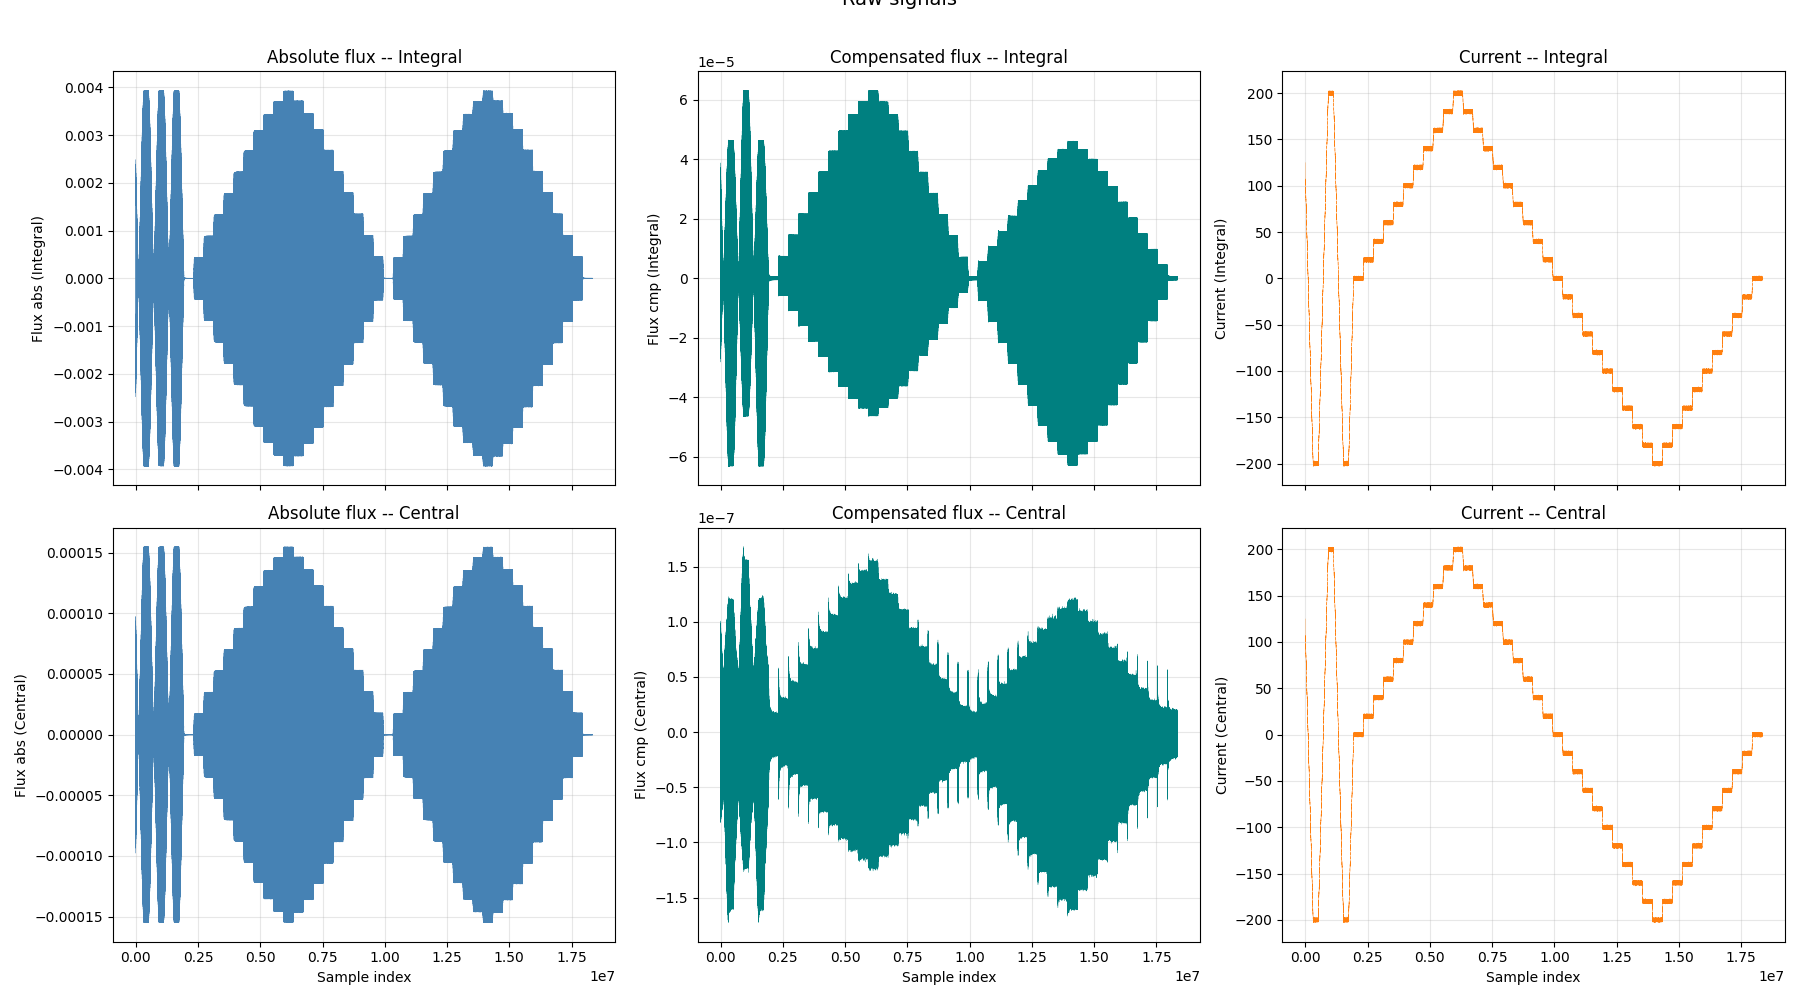

In [5]:
fig, axes = plt.subplots(len(SEGMENTS), 3, figsize=(18, 5 * len(SEGMENTS)), sharex="col")
if len(SEGMENTS) == 1:
    axes = axes[np.newaxis, :]

for i, seg in enumerate(SEGMENTS):
    d = data[seg]
    n_keep = d["n_turns"] * Ns
    x = np.arange(n_keep)
    axes[i, 0].plot(x, d["flux_abs"].ravel(), linewidth=0.2, color="steelblue")
    axes[i, 0].set_ylabel(f"Flux abs ({seg})")
    axes[i, 0].set_title(f"Absolute flux -- {seg}")
    axes[i, 1].plot(x, d["flux_cmp"].ravel(), linewidth=0.2, color="teal")
    axes[i, 1].set_ylabel(f"Flux cmp ({seg})")
    axes[i, 1].set_title(f"Compensated flux -- {seg}")
    axes[i, 2].plot(x, d["I_all"].ravel(), linewidth=0.2, color="tab:orange")
    axes[i, 2].set_ylabel(f"Current ({seg})")
    axes[i, 2].set_title(f"Current -- {seg}")

axes[-1, 0].set_xlabel("Sample index")
axes[-1, 1].set_xlabel("Sample index")
axes[-1, 2].set_xlabel("Sample index")
fig.suptitle("Raw signals", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. cel/fed Safety Diagnostic

Run `diagnose_cel_fed()` on Integral high-current turns.

In [6]:
# Diagnostic on main segment (not fringe)
_main_seg = "Integral"
d = data[_main_seg]
I_mean = d["I_all"].mean(axis=1)
hi_mask = np.abs(I_mean) > np.percentile(np.abs(I_mean), 90)
if hi_mask.sum() < 5:
    hi_mask = np.abs(I_mean) > np.median(np.abs(I_mean))

n_diag = min(100, int(hi_mask.sum()))
if n_diag == 0:
    print(f"No high-I turns in {_main_seg} for cel/fed diagnostic -- skipping")
else:
    hi_idx = np.where(hi_mask)[0][:n_diag]

    diag = diagnose_cel_fed(
        d["flux_abs"][hi_idx], d["flux_cmp"][hi_idx],
        d["t_all"][hi_idx], d["I_all"][hi_idx],
        kn=KN[_main_seg], r_ref=R_REF, magnet_order=MAGNET_ORDER,
    )
    print(f"cel/fed diagnostic ({n_diag} {_main_seg} high-I turns):")
    print(f"  Recommendation: {diag.recommendation}")
    print(f"  {diag.reason}")
    Bd = np.max(np.abs(diag.B_main_with_fed - diag.B_main_without_fed))
    print(f"  B_main max |diff|: {Bd:.4e} T")

    if diag.recommendation == "UNSAFE":
        OPTIONS = tuple(o for o in OPTIONS if o not in ("cel", "fed"))
        print(f"  -> cel/fed disabled, OPTIONS = {OPTIONS}")
    else:
        print(f"  -> cel/fed safe, keeping OPTIONS = {OPTIONS}")

cel/fed diagnostic (100 Integral high-I turns):
  Recommendation: UNSAFE
  100/100 turns (100%) have |zR| > 0.0100 (median 0.1174, max 0.1228). cel/fed produces unreliable offsets — skip it and use OPTIONS = ('dri', 'rot').
  B_main max |diff|: 1.4035e-05 T
  -> cel/fed disabled, OPTIONS = ('dri', 'rot')


---
## 6. Plateau Detection & Turn Classification


Integral: 33453 plateau turns, 4 groups
  Run 0: I=-200.0 A, ascending, 399 turns
  Run 1: I=+200.0 A, ascending, 400 turns
  Run 2: I=-200.0 A, descending, 401 turns
  Run 3: I=+0.0 A, ascending, 32042 turns

Central: 33453 plateau turns, 4 groups
  Run 0: I=-200.0 A, ascending, 399 turns
  Run 1: I=+200.0 A, ascending, 400 turns
  Run 2: I=-200.0 A, descending, 401 turns
  Run 3: I=+0.0 A, ascending, 32042 turns


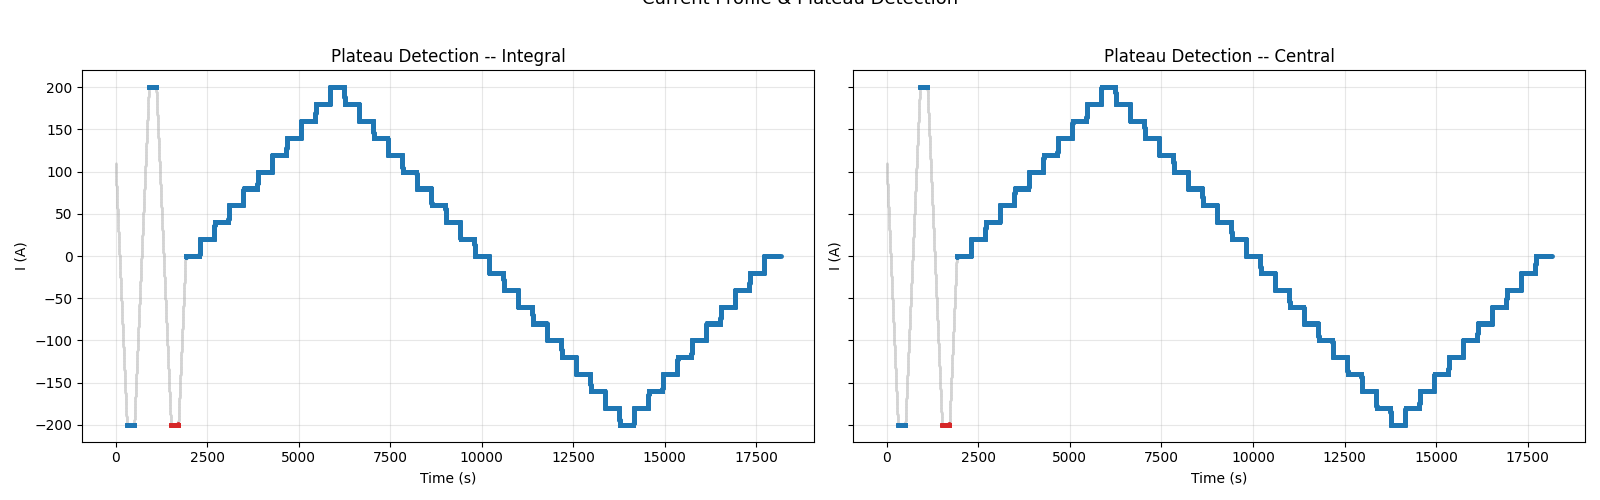

In [7]:
label_colors = {"ascending": "tab:blue", "descending": "tab:red"}

for seg in SEGMENTS:
    d = data[seg]
    I_mean = d["I_all"].mean(axis=1)
    t_mean = d["t_all"].mean(axis=1)
    I_range, I_blocks = compute_block_averaged_range(d["I_all"], Ns, N_BLOCKS)

    plateau_info = detect_plateau_turns(I_blocks, I_mean, I_range, PLATEAU_I_RANGE_MAX)
    is_plateau = plateau_info["is_plateau"]

    # Find contiguous plateau groups
    groups = find_contiguous_groups(is_plateau, min_length=PLATEAU_MIN_LENGTH)

    # Merge groups separated by small gaps
    if PLATEAU_MERGE_GAP > 0 and len(groups) > 1:
        merged = [groups[0]]
        for gs, ge in groups[1:]:
            prev_e = merged[-1][1]
            if gs - prev_e <= PLATEAU_MERGE_GAP:
                merged[-1] = (merged[-1][0], ge)
            else:
                merged.append((gs, ge))
        groups = merged

    # Build turn_run_map and classify branch
    turn_run_map = np.full(d["n_turns"], -1, dtype=int)
    run_info = []
    for gi, (gs, ge) in enumerate(groups):
        turn_run_map[gs:ge+1] = gi
        I_nom = float(np.median(I_mean[gs:ge+1]))
        branch = "ascending" if gi == 0 or I_nom >= run_info[-1]["I_nom"] else "descending"
        if gi > 0 and abs(I_nom - run_info[-1]["I_nom"]) < 1.0:
            branch = run_info[-1]["branch"]
        run_info.append({"run_id": gi, "start": gs, "end": ge,
                         "I_nom": I_nom, "branch": branch, "n_turns": ge - gs + 1})

    d.update({
        "I_mean": I_mean, "t_mean": t_mean, "I_range": I_range,
        "is_plateau": is_plateau, "groups": groups,
        "turn_run_map": turn_run_map, "run_info": run_info,
    })
    print(f"\n{seg}: {is_plateau.sum()} plateau turns, {len(groups)} groups")
    for ri in run_info[:5]:
        print(f"  Run {ri['run_id']}: I={ri['I_nom']:+.1f} A, {ri['branch']}, {ri['n_turns']} turns")
    if len(run_info) > 5:
        print(f"  ... ({len(run_info) - 5} more)")

# Plot
fig, axes = plt.subplots(1, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 5), sharey=True)
if len(SEGMENTS) == 1:
    axes = [axes]
for ax, seg in zip(axes, SEGMENTS):
    d = data[seg]
    ax.plot(d["t_mean"], d["I_mean"], ".-", markersize=1, linewidth=0.3, color="lightgrey", zorder=0)
    for ri in d["run_info"]:
        gs, ge = ri["start"], ri["end"]
        col = label_colors.get(ri["branch"], "tab:purple")
        ax.scatter(d["t_mean"][gs:ge+1], d["I_mean"][gs:ge+1], s=6, color=col, zorder=2)
    ax.set_xlabel("Time (s)"); ax.set_ylabel("I (A)")
    ax.set_title(f"Plateau Detection -- {seg}")
fig.suptitle("Current Profile & Plateau Detection", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 7. FDI Stuck-Channel Diagnostic

Check whether the FDI responds to current changes between plateau groups.

In [8]:
for seg in SEGMENTS:
    d = data[seg]
    run_info = d["run_info"]
    staircase_start = d.get("staircase_start_run", 0)
    _groups = [ri for ri in run_info if ri["run_id"] >= staircase_start]
    if len(_groups) < 2:
        print(f"{seg}: fewer than 2 groups, skipping FDI check")
        continue

    flux_turns = d["flux_abs"].mean(axis=1)
    checks = diagnose_fdi_transitions(
        flux_turns, d["I_mean"], _groups,
        stuck_threshold=0.3, partial_threshold=0.7, min_delta_I=5.0,
    )
    n_ok = sum(1 for c in checks if c.severity == "OK")
    n_stuck = sum(1 for c in checks if c.severity == "STUCK")
    print(f"\n{seg}: {len(checks)} transitions, OK={n_ok}, STUCK={n_stuck}")
    for c in checks:
        if c.severity != "OK":
            print(f"  ! Run {c.run_before}->{c.run_after}: {c.severity} -- {c.reason}")
    if n_stuck > 0:
        print(f"  WARNING: {n_stuck} stuck transitions!")
    else:
        print(f"  All transitions OK.")

C:\Users\albellel\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_nanfunctions_impl.py:1437: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(



Integral: 3 transitions, OK=3, STUCK=0
  All transitions OK.



Central: 3 transitions, OK=3, STUCK=0
  All transitions OK.


---
## 8. Precycle Identification

Separate precycle from staircase based on initial plateau pattern.

In [9]:
for seg in SEGMENTS:
    d = data[seg]
    run_info = d["run_info"]
    # Find first 0 A plateau with >= 500 turns -> staircase start
    staircase_start_run = 0
    for ri in run_info:
        if abs(ri["I_nom"]) < 1.0 and ri["n_turns"] >= 500:
            staircase_start_run = ri["run_id"]
            break
    # Check if pre-start groups are systematic steps (no real precycle)
    pre_runs = [ri for ri in run_info if ri["run_id"] < staircase_start_run]
    if pre_runs:
        steps = [abs(pre_runs[i+1]["I_nom"] - pre_runs[i]["I_nom"]) for i in range(len(pre_runs)-1)]
        if steps and max(steps) < 50:
            print(f"{seg}: pre-start groups appear to be systematic 20 A steps, not precycle")
            staircase_start_run = 0
    d["staircase_start_run"] = staircase_start_run
    n_pre = sum(1 for ri in run_info if ri["run_id"] < staircase_start_run)
    print(f"{seg}: staircase starts at run {staircase_start_run} ({n_pre} precycle runs)")

Integral: staircase starts at run 3 (3 precycle runs)
Central: staircase starts at run 3 (3 precycle runs)


---
## 9. Process Plateau Turns

Re-process plateau turns with the full pipeline. Group by supercycle/run, apply settling window and MAD sigma-clip.

In [10]:
results = {}

for seg in SEGMENTS:
    d = data[seg]
    run_info = d["run_info"]
    staircase_start = d.get("staircase_start_run", 0)
    kn_seg = KN[seg]
    _scfg = next(sc for sc in SEGMENT_CONFIGS if sc["name"] == seg)
    merge_mode = _scfg["merge_mode"]

    all_rows = []
    for ri in run_info:
        if ri["run_id"] < staircase_start:
            continue
        gs, ge = ri["start"], ri["end"]
        idx = np.arange(gs, ge + 1)
        result, C_merged, C_units, ok_main = process_kn_pipeline(
            flux_abs_turns=d["flux_abs"][idx],
            flux_cmp_turns=d["flux_cmp"][idx],
            t_turns=d["t_all"][idx],
            I_turns=d["I_all"][idx],
            kn=kn_seg, r_ref=R_REF, magnet_order=m,
            options=OPTIONS, min_b1_T=MIN_B1_T,
            encoder_offset_rad=ENCODER_OFFSET_RAD,
            merge_mode=merge_mode,
        )
        extra = [
            {"global_turn": int(idx[t]), "run_id": ri["run_id"],
              "I_nom": ri["I_nom"], "branch": ri["branch"],
              "turn_in_run": t, "segment": seg}
            for t in range(len(idx))
        ]
        rows = build_harmonic_rows(result, C_merged, C_units, ok_main, m, extra)
        all_rows.extend(rows)

    df_seg = pd.DataFrame(all_rows)
    # Apply N_LAST and sigma clip
    if N_SKIP_END > 0:
        summ_seg = plateau_summary(df_seg, N_LAST_TURNS, n_skip_end=N_SKIP_END)
    else:
        summ_seg = plateau_summary(df_seg, N_LAST_TURNS)
    n_before = len(summ_seg)
    summ_seg, clip_info = mad_sigma_clip(summ_seg, "B1_mean", N_SIGMA_CLIP, label_col="branch")
    n_clipped = n_before - len(summ_seg)
    if n_clipped > 0:
        print(f"  {seg}: sigma clip removed {n_clipped} rows ({clip_info})")

    # Transfer function
    df_seg["TF_TperkA"] = df_seg["B1_T"] / (df_seg["I_mean_A"] / 1000.0)
    if "I_mean_A" in summ_seg.columns:
        summ_seg["TF_TperkA"] = summ_seg["B1_mean"] / (summ_seg["I_nom"] / 1000.0)

    results[seg] = {"df": df_seg, "summ": summ_seg}
    print(f"{seg}: {len(df_seg)} all turns, {len(summ_seg)} summary rows")

Integral: 32042 all turns, 1 summary rows


Central: 32042 all turns, 1 summary rows


---
## 10. All-Turn Harmonics vs Time

Process all turns (including ramps) to show B1, b2, b3 evolution.

Integral: 35828 all-turns processed, ok_main=35827


Central: 35828 all-turns processed, ok_main=35827


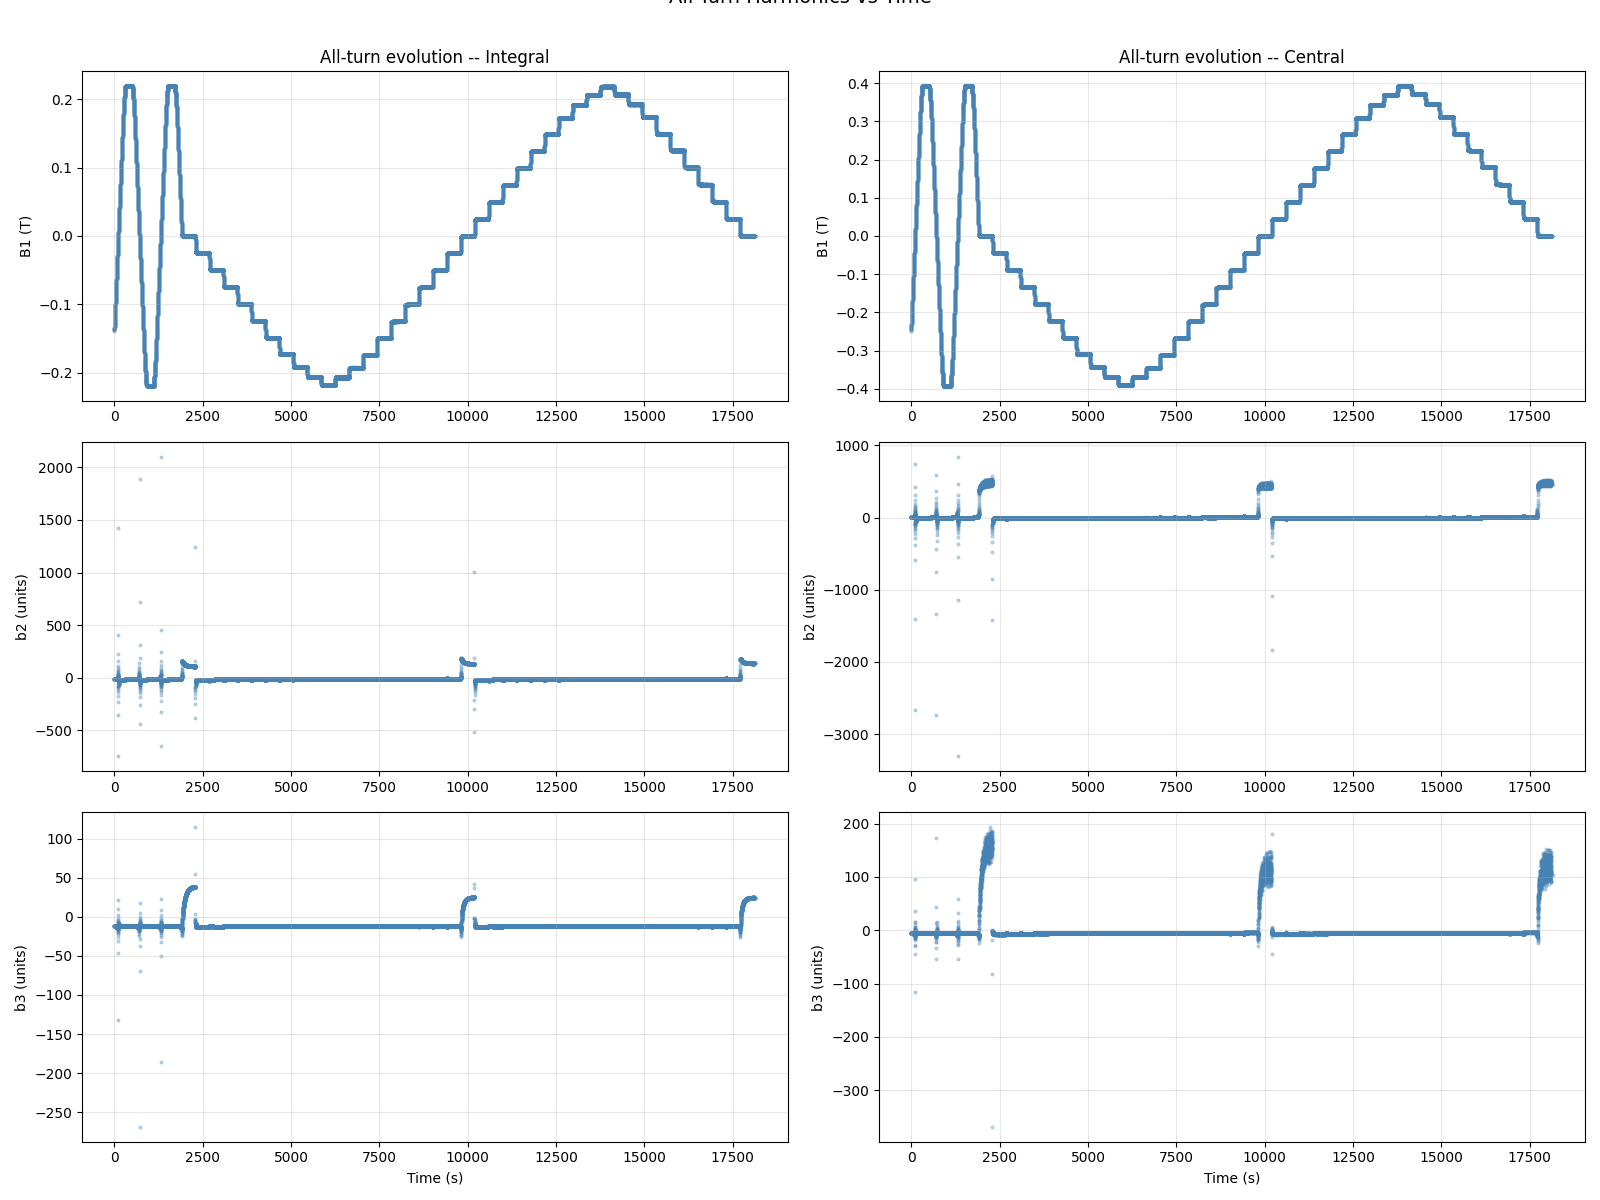

In [11]:
all_turn_dfs = {}

for seg in SEGMENTS:
    d = data[seg]
    kn_seg = KN[seg]

    result_all, C_merged_all, C_units_all, ok_main_all = process_kn_pipeline(
        flux_abs_turns=d["flux_abs"], flux_cmp_turns=d["flux_cmp"],
        t_turns=d["t_all"], I_turns=d["I_all"],
        kn=kn_seg, r_ref=R_REF, magnet_order=m,
        options=OPTIONS, min_b1_T=MIN_B1_T,
    )

    extra_all = [{"global_turn": int(i), "segment": seg} for i in range(d["n_turns"])]
    rows_all = build_harmonic_rows(result_all, C_merged_all, C_units_all, ok_main_all, m, extra_all)
    df_all = pd.DataFrame(rows_all)
    df_all["t_mean_s"] = d["t_mean"]
    all_turn_dfs[seg] = df_all
    print(f"{seg}: {d['n_turns']} all-turns processed, ok_main={ok_main_all.sum()}")

# Plot B1, b2, b3 vs time
fig, axes = plt.subplots(3, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 12))
if len(SEGMENTS) == 1:
    axes = axes[:, np.newaxis]

for j, seg in enumerate(SEGMENTS):
    df_all = all_turn_dfs[seg]
    ok = df_all["ok_main"]
    for ax_idx, (col, ylabel) in enumerate([("B1_T", "B1 (T)"), ("b2_units", "b2 (units)"), ("b3_units", "b3 (units)")]):
        ax = axes[ax_idx, j]
        ax.scatter(df_all.loc[ok, "t_mean_s"], df_all.loc[ok, col],
                   s=4, alpha=0.3, color="steelblue", zorder=1)
        ax.set_ylabel(ylabel)
        if ax_idx == 0:
            ax.set_title(f"All-turn evolution -- {seg}")
        if ax_idx == 2:
            ax.set_xlabel("Time (s)")

fig.suptitle("All-Turn Harmonics vs Time", fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

---
## 11. FFMM Golden Standard Validation

Compare pipeline output against FFMM per-turn and average results.

In [12]:
OPTIONS_FFMM = ('dri', 'rot', 'cel', 'fed', 'dit')
FFMM_ROTATE_EXCLUDES_LAST = False

print("=" * 70)
print("FFMM GOLDEN STANDARD COMPARISON")
print(f"FFMM pipeline options: {OPTIONS_FFMM}")
print(f"legacy_rotate_excludes_last = {FFMM_ROTATE_EXCLUDES_LAST}")
print("=" * 70)

# This section expects FFMM result files alongside the raw data.
# Adjust paths as needed for your measurement.
print("(FFMM validation section -- configure paths for your measurement)")

FFMM GOLDEN STANDARD COMPARISON
FFMM pipeline options: ('dri', 'rot', 'cel', 'fed', 'dit')
legacy_rotate_excludes_last = False
(FFMM validation section -- configure paths for your measurement)


---
## 12. Main Field (B1)

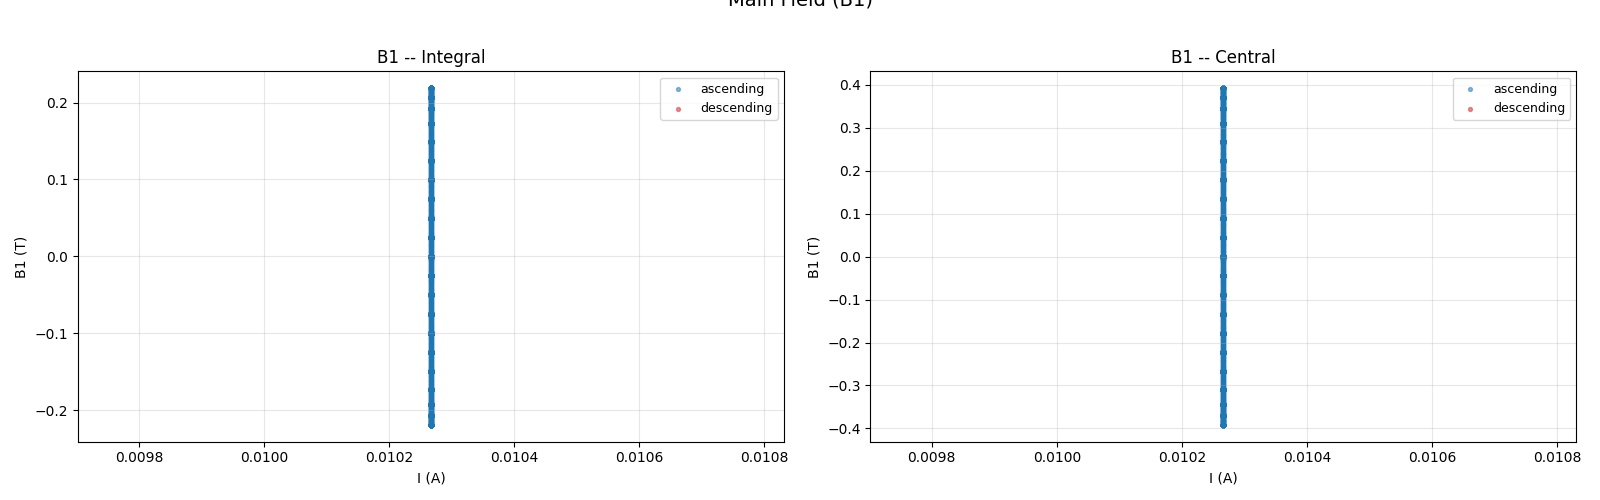

In [13]:
fig, axes = plt.subplots(1, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 5))
if len(SEGMENTS) == 1:
    axes = [axes]
for ax_idx, seg in enumerate(SEGMENTS):
    _df = results[seg]["df"]
    ok = _df["ok_main"]
    for branch, col in [("ascending", "tab:blue"), ("descending", "tab:red")]:
        mask = ok & (_df["branch"] == branch)
        ax = axes[ax_idx]
        ax.scatter(_df.loc[mask, "I_nom"], _df.loc[mask, "B1_T"],
                   s=8, alpha=0.5, color=col, label=branch)
    
    axes[ax_idx].set_xlabel("I (A)"); axes[ax_idx].set_ylabel("B1 (T)")
    axes[ax_idx].set_title(f"B1 -- {seg}"); axes[ax_idx].legend(fontsize=9)
fig.suptitle("Main Field (B1)", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---
## 13. b2 (Quadrupole) -- first allowed harmonic error

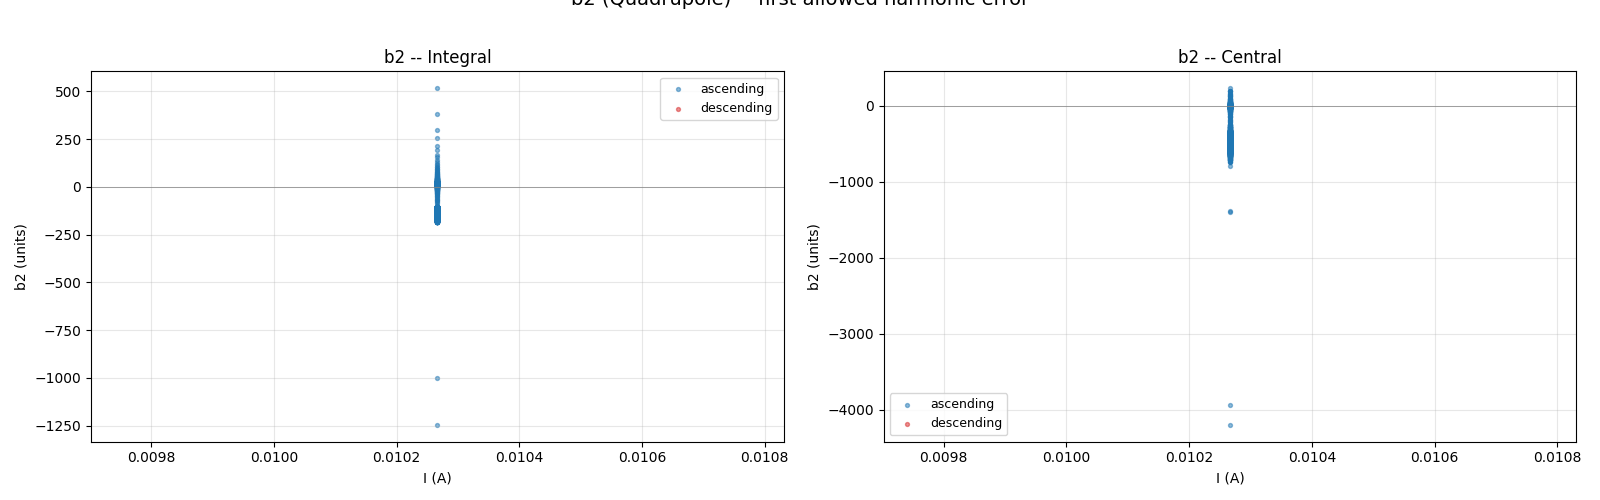

In [14]:
fig, axes = plt.subplots(1, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 5))
if len(SEGMENTS) == 1:
    axes = [axes]
for ax_idx, seg in enumerate(SEGMENTS):
    _df = results[seg]["df"]
    ok = _df["ok_main"]
    for branch, col in [("ascending", "tab:blue"), ("descending", "tab:red")]:
        mask = ok & (_df["branch"] == branch)
        ax = axes[ax_idx]
        ax.scatter(_df.loc[mask, "I_nom"], _df.loc[mask, "b2_units"],
                   s=8, alpha=0.5, color=col, label=branch)
    ax.axhline(0, color="grey", linewidth=0.5)
    axes[ax_idx].set_xlabel("I (A)"); axes[ax_idx].set_ylabel("b2 (units)")
    axes[ax_idx].set_title(f"b2 -- {seg}"); axes[ax_idx].legend(fontsize=9)
fig.suptitle("b2 (Quadrupole) -- first allowed harmonic error", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---
## 14. b3 (Sextupole) -- first non-allowed harmonic

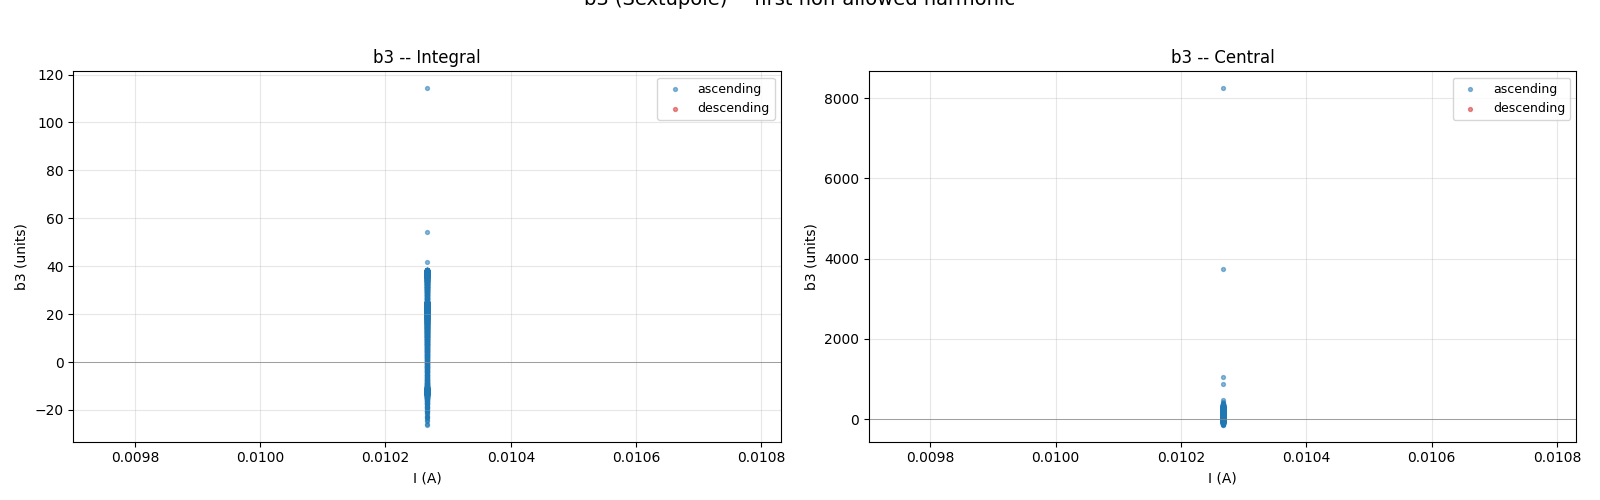

In [15]:
fig, axes = plt.subplots(1, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 5))
if len(SEGMENTS) == 1:
    axes = [axes]
for ax_idx, seg in enumerate(SEGMENTS):
    _df = results[seg]["df"]
    ok = _df["ok_main"]
    for branch, col in [("ascending", "tab:blue"), ("descending", "tab:red")]:
        mask = ok & (_df["branch"] == branch)
        ax = axes[ax_idx]
        ax.scatter(_df.loc[mask, "I_nom"], _df.loc[mask, "b3_units"],
                   s=8, alpha=0.5, color=col, label=branch)
    ax.axhline(0, color="grey", linewidth=0.5)
    axes[ax_idx].set_xlabel("I (A)"); axes[ax_idx].set_ylabel("b3 (units)")
    axes[ax_idx].set_title(f"b3 -- {seg}"); axes[ax_idx].legend(fontsize=9)
fig.suptitle("b3 (Sextupole) -- first non-allowed harmonic", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---
## 15. Higher Harmonics Overview

Statistics for all harmonics at key operating points (Integral).

In [16]:
seg = "Integral"
if "binary_streaming" == "file_discovery":
    _peak_mask = summ[seg]["I_nom"].abs() == summ[seg]["I_nom"].abs().max()
    _peak = summ[seg][_peak_mask]
    _bn_cols = sorted([c for c in summ[seg].columns if c.endswith("_mean")
                       and (c.startswith("b") or c.startswith("a"))
                       and c not in ("b2_units_mean", "b3_units_mean")],
                      key=lambda c: (c[0], int(c.split("_")[0][1:])))
    if _peak.empty or not _bn_cols:
        print("No peak-current data or harmonic columns found.")
    else:
        rows_tbl = []
        for col in _bn_cols:
            base = col.replace("_mean", "")
            std_col = base + "_std"
            mean_val = _peak[col].values[0]
            std_val = _peak[std_col].values[0] if std_col in _peak.columns else float("nan")
            rows_tbl.append({"Harmonic": base, "Mean [units]": mean_val, "Std [units]": std_val})
        _htable = pd.DataFrame(rows_tbl)
        print(f"Higher harmonics at peak |I| ({seg}):")
        print(_htable.to_string(index=False, float_format="%.3f"))
else:
    _df = results[seg]["df"]
    _summ = results[seg]["summ"]
    if not _summ.empty:
        _peak_mask = _summ["I_nom"].abs() == _summ["I_nom"].abs().max()
        _peak = _summ[_peak_mask]
        print(f"Higher harmonics at peak |I| ({seg}):")
        _bn_cols = sorted([c for c in _summ.columns if ("_mean" in c)
                           and (c.startswith("b") or c.startswith("a"))
                           and c not in ("b2_units_mean", "b3_units_mean", "B1_mean")],
                          key=lambda c: (c[0], int(c.split("_")[0][1:])))
        for col in _bn_cols[:20]:
            vals = _peak[col].values
            print(f"  {col}: {vals[0]:.4f}" if len(vals) > 0 else f"  {col}: --")

Higher harmonics at peak |I| (Integral):
  a2_units_mean: -239.0624
  a3_units_mean: 27.9326
  a4_units_mean: 7.3160
  a5_units_mean: -4.9137
  a6_units_mean: -1.4846
  a7_units_mean: 1.0886
  a8_units_mean: -0.4674
  a9_units_mean: -0.1462
  a10_units_mean: 0.2117
  a11_units_mean: -0.0906
  a12_units_mean: -0.0062
  a13_units_mean: 0.0212
  a14_units_mean: 0.0101
  a15_units_mean: -0.0082
  b4_units_mean: 3.1568
  b5_units_mean: 2.4317
  b6_units_mean: -1.6974
  b7_units_mean: -0.1097
  b8_units_mean: 0.7701
  b9_units_mean: -0.4404


---
## 16. Multipole Spectrum

Bar charts of normal (bn) and skew (an) harmonics.

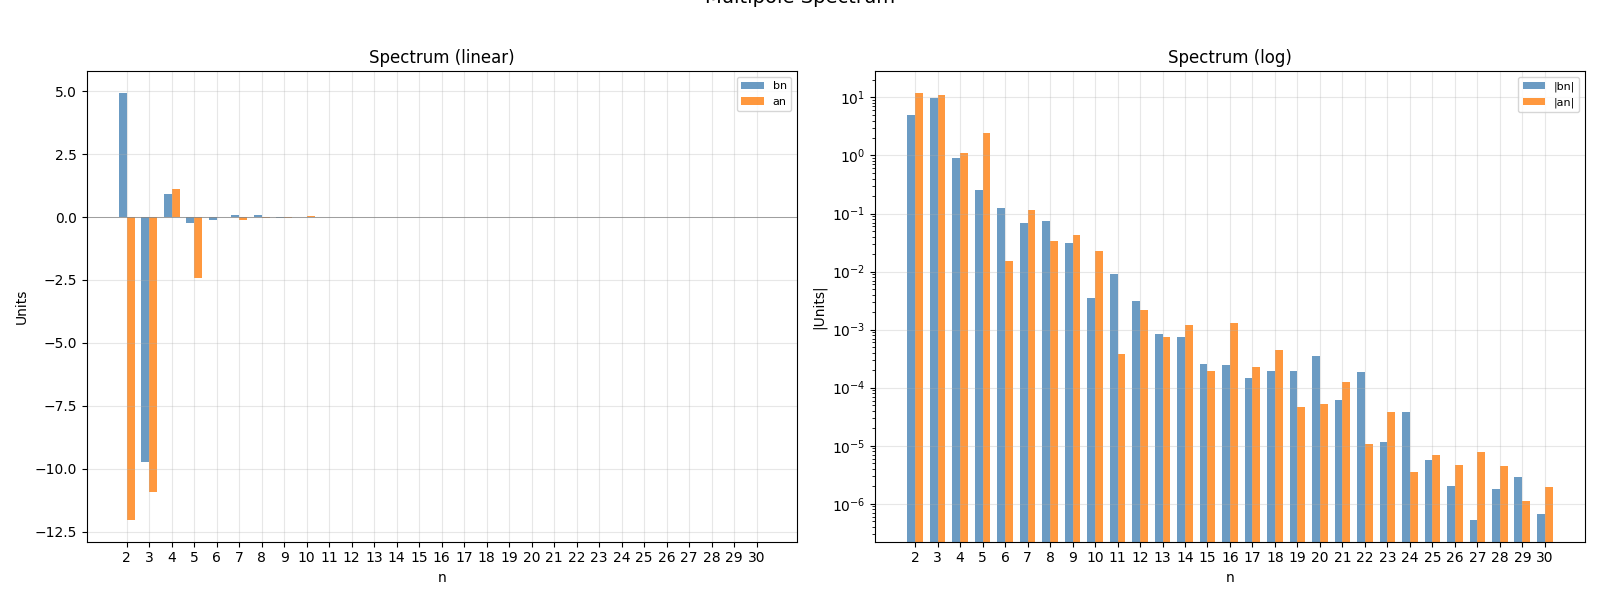

In [17]:
seg = "Integral"
# Detect available harmonic orders from columns
if "binary_streaming" == "file_discovery":
    _cols = df[seg].columns
else:
    _cols = results[seg]["df"].columns
bn_cols = [c for c in _cols if c.startswith("b") and c.endswith("_units") and c != "b1_units"]
orders = sorted([int(c.replace("b", "").replace("_units", "")) for c in bn_cols])

if orders:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    x = np.arange(len(orders))
    w = 0.35

    if "binary_streaming" == "file_discovery":
        _src = df[seg][df[seg]["ok_main"]]
    else:
        _src = results[seg]["df"][results[seg]["df"]["ok_main"]]

    bn_means = [_src[f"b{nn}_units"].mean() for nn in orders]
    an_means = [_src[f"a{nn}_units"].mean() for nn in orders]

    ax = axes[0]
    ax.bar(x - w/2, bn_means, w, label="bn", color="steelblue", alpha=0.8)
    ax.bar(x + w/2, an_means, w, label="an", color="tab:orange", alpha=0.8)
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_xticks(x); ax.set_xticklabels(orders)
    ax.set_xlabel("n"); ax.set_ylabel("Units")
    ax.set_title("Spectrum (linear)"); ax.legend(fontsize=8)

    ax = axes[1]
    ax.bar(x - w/2, np.abs(bn_means), w, label="|bn|", color="steelblue", alpha=0.8)
    ax.bar(x + w/2, np.abs(an_means), w, label="|an|", color="tab:orange", alpha=0.8)
    ax.set_yscale("log")
    ax.set_xticks(x); ax.set_xticklabels(orders)
    ax.set_xlabel("n"); ax.set_ylabel("|Units|")
    ax.set_title("Spectrum (log)"); ax.legend(fontsize=8)

    fig.suptitle("Multipole Spectrum", fontsize=14, y=1.02)
    plt.tight_layout(); plt.show()
else:
    print("No harmonic columns found for spectrum plot.")

---
## 17. Transfer Function B1/I

TF = B1 / I (units: T/kA).

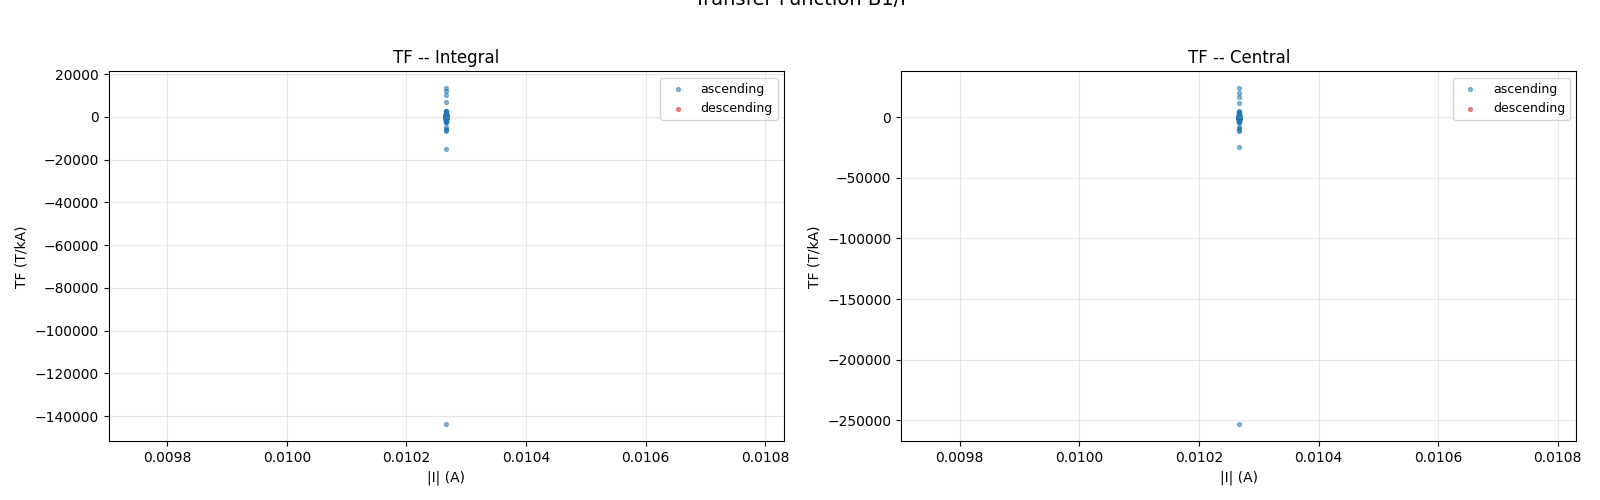

In [18]:
fig, axes = plt.subplots(1, len(SEGMENTS), figsize=(8 * len(SEGMENTS), 5))
if len(SEGMENTS) == 1:
    axes = [axes]
for ax_idx, seg in enumerate(SEGMENTS):
    if "binary_streaming" == "file_discovery":
        _df = df[seg][df[seg]["ok_main"]]
    else:
        _df = results[seg]["df"][results[seg]["df"]["ok_main"]]
    _df_tf = _df.copy()
    _df_tf["TF"] = _df_tf["B1_T"] / (_df_tf["I_mean_A"] / 1000.0)
    for branch, col in [("ascending", "tab:blue"), ("descending", "tab:red")]:
        mask = _df_tf["branch"] == branch
        axes[ax_idx].scatter(_df_tf.loc[mask, "I_nom"].abs(), _df_tf.loc[mask, "TF"],
                             s=8, alpha=0.5, color=col, label=branch)
    axes[ax_idx].set_xlabel("|I| (A)"); axes[ax_idx].set_ylabel("TF (T/kA)")
    axes[ax_idx].set_title(f"TF -- {seg}"); axes[ax_idx].legend(fontsize=9)
fig.suptitle("Transfer Function B1/I", fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

---
## 18. Apparent vs Differential Inductance

**L_app** = B1/I, **L_d** = dB1/dI (from paired current levels).

In [19]:
print("Inductance analysis for staircase data:")
for seg in SEGMENTS:
    if "file_discovery" == "binary_streaming": _s = summ[seg]
    else: _s = results[seg]["summ"]
    if _s.empty:
        continue
    _s_ok = _s[_s["B1_mean"].notna()].copy()
    _s_ok["TF"] = _s_ok["B1_mean"] / (_s_ok["I_nom"] / 1000.0)
    for branch in ["ascending", "descending"]:
        sub = _s_ok[_s_ok["branch"] == branch].sort_values("I_nom")
        if len(sub) >= 2:
            # Compute Ld between consecutive steps
            dB = np.diff(sub["B1_mean"].values)
            dI = np.diff(sub["I_nom"].values) / 1000.0
            Ld = dB / dI
            valid = np.abs(dI) > 0.001
            if valid.any():
                print(f"  {seg} {branch}: Ld range = {Ld[valid].min():.4f} .. {Ld[valid].max():.4f} T/kA")

Inductance analysis for staircase data:


---
## 19. Eddy Current Settling Analysis

Turn-by-turn B1 for all runs. Eddy currents cause exponential decay.

In [20]:
from rotating_coil_analyzer.analysis.utility_functions import fit_eddy_per_run

MIN_I_FOR_FIT = 10.0


# Use first segment for eddy analysis
_eddy_seg = SEGMENTS[0]
df_eddy = results[_eddy_seg]["df"].copy()
print(f"Eddy analysis: {len(df_eddy)} turns, {df_eddy['run_id'].nunique()} runs")

Eddy analysis: 32042 turns, 1 runs


### Raw B1 settling curves

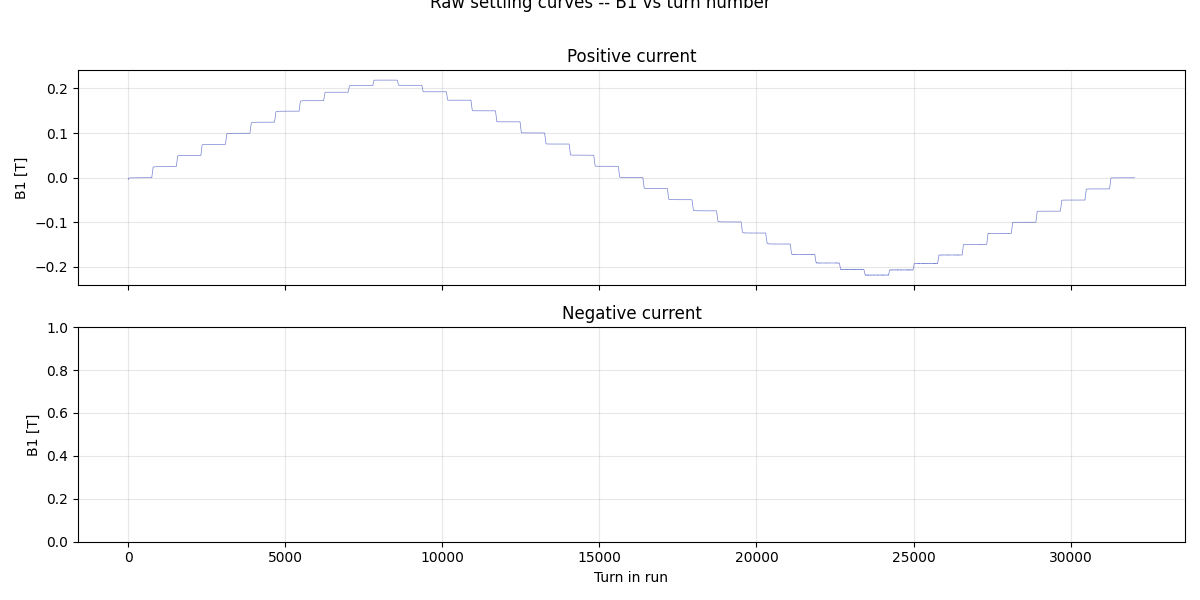

In [21]:
_I_noms = sorted(df_eddy["I_nom"].unique())
if len(_I_noms) == 0:
    print("No eddy data to plot")
else:
    cmap = plt.cm.coolwarm
    _norm_c = plt.Normalize(min(_I_noms), max(_I_noms))

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    for sign_idx, (sign_label, sign_cond) in enumerate([("Positive current", lambda x: x > 0), ("Negative current", lambda x: x < 0)]):
        ax = axes[sign_idx]
        for run_id in sorted(df_eddy["run_id"].unique()):
            rdf = df_eddy[(df_eddy["run_id"] == run_id) & df_eddy["ok_main"]]
            if rdf.empty: continue
            I_nom = rdf["I_nom"].iloc[0]
            if not sign_cond(I_nom): continue
            ax.plot(rdf["turn_in_run"], rdf["B1_T"], lw=0.5,
                    color=cmap(_norm_c(I_nom)), alpha=0.7)
        ax.set_ylabel("B1 [T]"); ax.set_title(sign_label)
    axes[-1].set_xlabel("Turn in run")
    fig.suptitle("Raw settling curves -- B1 vs turn number", y=1.01)
    fig.tight_layout(); plt.show()

---
## 20. Exponential Fits

Fit single-exponential eddy model per run/supercycle.

In [22]:
_fit_results = []
for run_id in sorted(df_eddy["run_id"].unique()):
    rdf = df_eddy[(df_eddy["run_id"] == run_id) & df_eddy["ok_main"]].sort_values("turn_in_run")
    if rdf.empty: continue
    I_nom = rdf["I_nom"].iloc[0]
    if abs(I_nom) < MIN_I_FOR_FIT: continue
    branch = rdf["branch"].iloc[0]
    I_mean = rdf["I_mean"].values if "I_mean" in rdf.columns else None
    res = fit_eddy_per_run(
        turns=rdf["turn_in_run"].values.astype(float),
        B1=rdf["B1_T"].values,
        run_id=run_id, I_nom=I_nom, branch=branch, I_mean=I_mean,
    )
    _fit_results.append(res)

_cols = ["run_id", "I_nom", "branch", "B_inf", "A", "tau", "tau_err",
         "tau_s", "tau_err_s", "r2", "n_turns", "quality", "reason"]
if _fit_results:
    df_fits_all = pd.DataFrame([
        {"run_id": r.run_id, "I_nom": r.I_nom, "branch": r.branch,
         "B_inf": r.B_inf, "A": r.A, "tau": r.tau, "tau_err": r.tau_err,
         "tau_s": r.tau * T_PER_TURN, "tau_err_s": r.tau_err * T_PER_TURN,
         "r2": r.r2, "n_turns": r.n_turns, "quality": r.quality, "reason": r.reason}
        for r in _fit_results
    ])
else:
    df_fits_all = pd.DataFrame(columns=_cols)

df_fits = df_fits_all[df_fits_all["quality"] == "GOOD"].copy()
print(f"Fits: {len(df_fits)} GOOD / {len(df_fits_all)} total")
if len(df_fits_all) > 0:
    print(f"{'Run':>4s} {'I [A]':>8s} {'tau [s]':>8s} {'R2':>8s} {'Quality':>12s}")
    print("-" * 50)
    for _, r in df_fits_all.iterrows():
        print(f"{r['run_id']:4.0f} {r['I_nom']:+8.1f} {r['tau_s']:8.2f} {r['r2']:8.4f} {r['quality']:>12s}")
else:
    print("No eddy fits produced (no qualifying runs)")

Fits: 0 GOOD / 0 total
No eddy fits produced (no qualifying runs)


### Tau vs Current

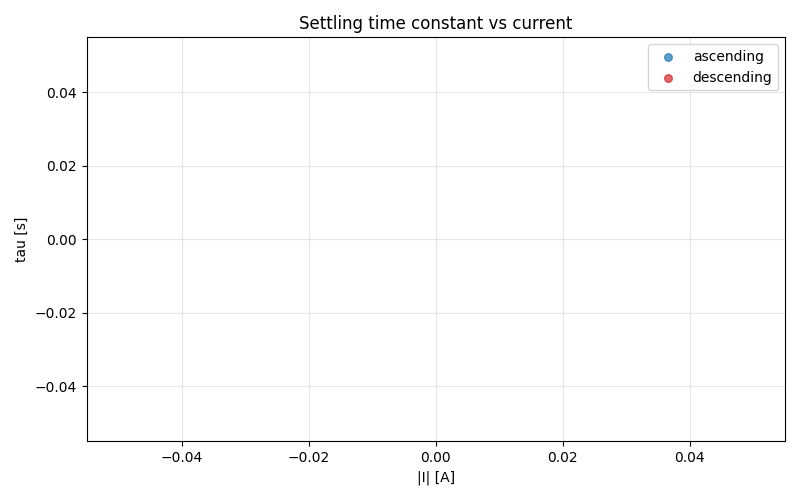

In [23]:
_branch_colors = {"ascending": "tab:blue", "descending": "tab:red"}
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
for branch, col in _branch_colors.items():
    mask = df_fits["branch"] == branch
    ax.scatter(df_fits.loc[mask, "I_nom"].abs(), df_fits.loc[mask, "tau_s"],
               c=col, label=branch, s=30, alpha=0.7)
ax.set_xlabel("|I| [A]"); ax.set_ylabel("tau [s]")
ax.set_title("Settling time constant vs current"); ax.legend()
plt.tight_layout(); plt.show()

if len(df_fits) > 0:
    print(f"Tau range: {df_fits['tau_s'].min():.1f} -- {df_fits['tau_s'].max():.1f} s")

---
## 21. Settling Bias Analysis

How b2/b3 averages change with averaging window.

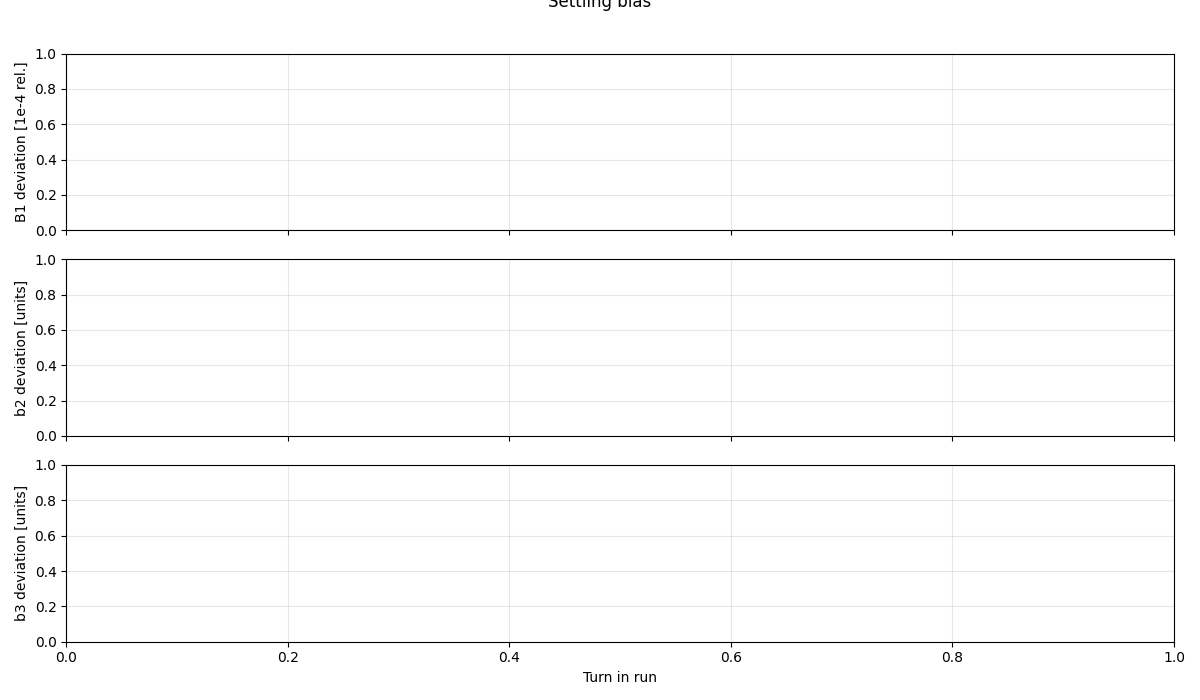

In [24]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
_show_runs = [r for _, r in df_fits.iterrows()]
_show_runs = _show_runs[::max(1, len(_show_runs) // 8)]

for quantity, col_name, ax, ylabel in [
    ("B1", "B1_T", axes[0], "B1 deviation [1e-4 rel.]"),
    ("b2", "b2_units", axes[1], "b2 deviation [units]"),
    ("b3", "b3_units", axes[2], "b3 deviation [units]"),
]:
    for row in _show_runs:
        run_id = row["run_id"]
        rdf = df_eddy[(df_eddy["run_id"] == run_id) & df_eddy["ok_main"]].sort_values("turn_in_run")
        if rdf.empty or col_name not in rdf.columns: continue
        vals = rdf[col_name].values
        ref = vals[-N_LAST_TURNS:].mean() if len(vals) >= N_LAST_TURNS else vals[-10:].mean()
        if quantity == "B1":
            dev = (vals - ref) / abs(ref) * 1e4 if abs(ref) > 1e-9 else vals - ref
        else:
            dev = vals - ref
        ax.plot(rdf["turn_in_run"].values, dev, lw=0.5, alpha=0.6)
    ax.set_ylabel(ylabel); ax.axhline(0, color="k", lw=0.5)
axes[-1].set_xlabel("Turn in run")
fig.suptitle("Settling bias", y=1.01); fig.tight_layout(); plt.show()

---
## 22. N_LAST Sensitivity Study

Scan N_LAST and show convergence.

In [25]:
_n_last_values = np.arange(50, 701, 10)
_study_runs = df_fits["run_id"].unique()

_results_sweep = []
for _nl in _n_last_values:
    _B1_errs = []
    for run_id in _study_runs:
        rdf = df_eddy[(df_eddy["run_id"] == run_id) & df_eddy["ok_main"]].sort_values("turn_in_run")
        if len(rdf) < _nl + 20: continue
        B1_true = rdf["B1_T"].values[-20:].mean()
        B1_est = rdf["B1_T"].values[-_nl:].mean()
        _B1_errs.append((B1_est - B1_true) / abs(B1_true) * 1e4)
    if _B1_errs:
        _results_sweep.append({"N_LAST": _nl, "B1_bias": np.mean(_B1_errs), "B1_std": np.std(_B1_errs)})

_df_sweep = pd.DataFrame(_results_sweep)
if not _df_sweep.empty:
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    ax.fill_between(_df_sweep["N_LAST"],
                    _df_sweep["B1_bias"] - _df_sweep["B1_std"],
                    _df_sweep["B1_bias"] + _df_sweep["B1_std"], alpha=0.2, color="tab:blue")
    ax.plot(_df_sweep["N_LAST"], _df_sweep["B1_bias"], ".-", color="tab:blue")
    ax.axhline(0, color="k", lw=0.5)
    ax.axvline(N_LAST_TURNS, color="red", ls="--", lw=1, label=f"N_LAST = {N_LAST_TURNS}")
    ax.set_xlabel("N_LAST"); ax.set_ylabel("B1 bias [1e-4 rel.]")
    ax.set_title("B1 systematic bias vs averaging window"); ax.legend()
    plt.tight_layout(); plt.show()

---
## 23. Comprehensive Statistics Table

In [26]:
print("=" * 70)
print("LEAR MC62 -- 03 Staircase 2 Hz (Afternoon)")
print("=" * 70)

for seg in SEGMENTS:
    if "binary_streaming" == "file_discovery":
        _s = summ[seg]
    else:
        _s = results[seg]["summ"]
    if _s.empty:
        print(f"\n{seg}: no summary data")
        continue
    print(f"\n--- {seg} ---")
    print(f"  Summary rows: {len(_s)}")
    if "I_nom" in _s.columns:
        print(f"  I range: {_s['I_nom'].min():.1f} .. {_s['I_nom'].max():.1f} A")
    if "B1_mean" in _s.columns:
        print(f"  B1 range: {_s['B1_mean'].min():.6f} .. {_s['B1_mean'].max():.6f} T")

LEAR MC62 -- 03 Staircase 2 Hz (Afternoon)

--- Integral ---
  Summary rows: 1
  I range: 0.0 .. 0.0 A
  B1 range: -0.000418 .. -0.000418 T

--- Central ---
  Summary rows: 1
  I range: 0.0 .. 0.0 A
  B1 range: -0.000693 .. -0.000693 T


---
## 24. Analysis Choices Summary

Document all analysis parameters for reproducibility.

In [27]:
import datetime
print("ANALYSIS CHOICES")
print("=" * 60)
print(f"Generated    : {datetime.datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"Title        : LEAR MC62 -- 03 Staircase 2 Hz (Afternoon)")
print(f"Segments     : {SEGMENTS}")
print(f"Magnet order : {MAGNET_ORDER}")
print(f"R_ref        : {R_REF} m")
print(f"Samples/turn : {SAMPLES_PER_TURN}")
print(f"OPTIONS      : {OPTIONS}")
print(f"MIN_B1_T     : {MIN_B1_T}")
print(f"N_SIGMA_CLIP : {N_SIGMA_CLIP}")

ANALYSIS CHOICES
Generated    : 2026-03-01 10:17
Title        : LEAR MC62 -- 03 Staircase 2 Hz (Afternoon)
Segments     : ['Integral', 'Central']
Magnet order : 1
R_ref        : 0.033 m
Samples/turn : 512
OPTIONS      : ('dri', 'rot')
MIN_B1_T     : 1e-06
N_SIGMA_CLIP : 5.0


---
## 25. CSV Export

In [28]:
out_dir = REPO_ROOT / "output" / "MC62/03_2Hz_afternoon"
out_dir.mkdir(parents=True, exist_ok=True)

for seg in SEGMENTS:
    _df = results[seg]["df"]
    fname = f"MC62_{seg}_all_turns.csv"
    _df.to_csv(out_dir / fname, index=False)
    print(f"Wrote {out_dir / fname}  ({len(_df)} rows)")

    _s = results[seg]["summ"]
    fname_s = f"MC62_{seg}_summary.csv"
    _s.to_csv(out_dir / fname_s, index=False)
    print(f"Wrote {out_dir / fname_s}  ({len(_s)} rows)")

print("\nDone.")

Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MC62\03_2Hz_afternoon\MC62_Integral_all_turns.csv  (32042 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MC62\03_2Hz_afternoon\MC62_Integral_summary.csv  (1 rows)


Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MC62\03_2Hz_afternoon\MC62_Central_all_turns.csv  (32042 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\MC62\03_2Hz_afternoon\MC62_Central_summary.csv  (1 rows)

Done.
